<a href="https://colab.research.google.com/github/fernandocosta-gcp/ace-module2-lab/blob/main/grafo_simples_relacoes_familiares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O grau do vértice que te representa (Fernando) é: 3
Conexões de Fernando: ['Carlos Silva', 'Beatriz Santos', 'Lucas Silva']



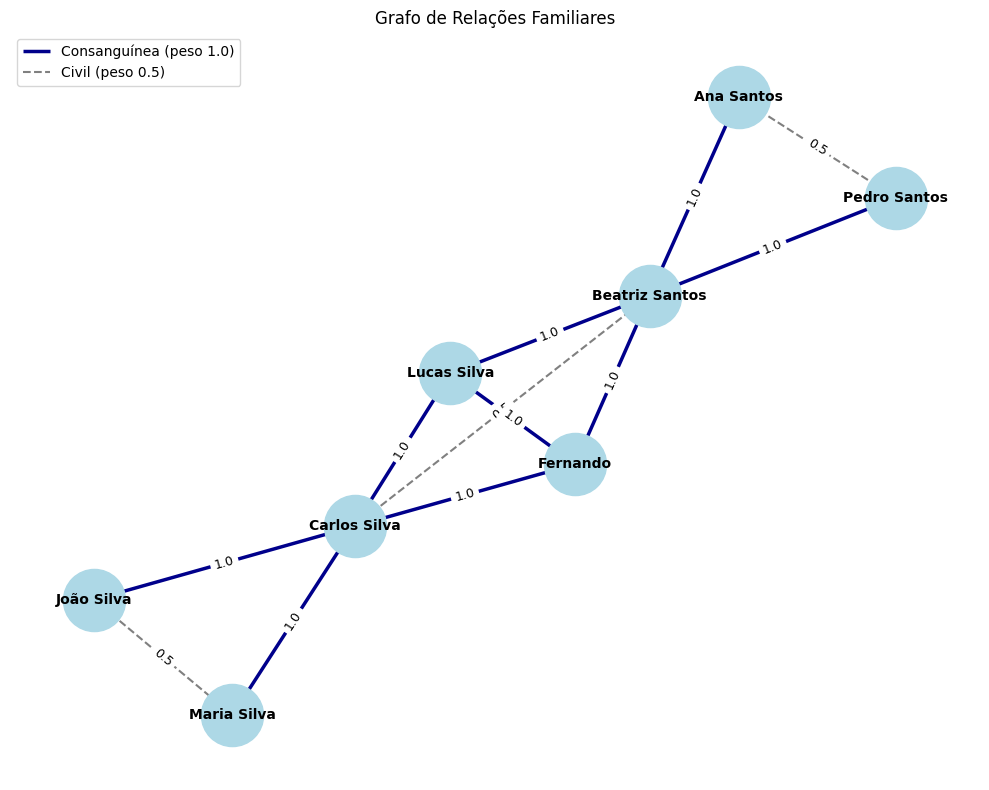

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Criar o grafo não direcionado
G = nx.Graph()

# Definindo os membros da família (Vértices)
vo_paterno = "João Silva"
vo_materno = "Pedro Santos"
voa_paterna = "Maria Silva"
voa_materna = "Ana Santos"
pai = "Carlos Silva"
mae = "Beatriz Santos"
irmao = "Lucas Silva"
usuario = "Fernando"

# 2. Adicionar vértices
G.add_nodes_from([vo_paterno, vo_materno, voa_paterna, voa_materna, pai, mae, irmao, usuario])

# 3. Adicionar arestas com pesos
# Relações consanguíneas (peso 1.0) e relações civis/casamento (peso 0.5)

# Avós Paternos -> Pai
G.add_edge(vo_paterno, pai, weight=1.0)
G.add_edge(voa_paterna, pai, weight=1.0)

# Avós Maternos -> Mãe
G.add_edge(vo_materno, mae, weight=1.0)
G.add_edge(voa_materna, mae, weight=1.0)

# Casamento dos avós (Relação civil: peso 0.5)
G.add_edge(vo_paterno, voa_paterna, weight=0.5)
G.add_edge(vo_materno, voa_materna, weight=0.5)

# Casamento dos pais (Relação civil: peso 0.5)
G.add_edge(pai, mae, weight=0.5)

# Pais -> Filhos (Consanguínea: peso 1.0)
G.add_edge(pai, usuario, weight=1.0)
G.add_edge(mae, usuario, weight=1.0)
G.add_edge(pai, irmao, weight=1.0)
G.add_edge(mae, irmao, weight=1.0)

# Irmãos (Consanguínea: peso 1.0)
G.add_edge(usuario, irmao, weight=1.0)

# 4. Calcular o grau do vértice que te representa
grau_usuario = G.degree(usuario)
print(f"O grau do vértice que te representa ({usuario}) é: {grau_usuario}")
print(f"Conexões de {usuario}: {list(G.neighbors(usuario))}\n")

# 5. Desenhar o grafo
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42) # Layout para posicionar os nós

# Desenhar nós
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')

# Desenhar rótulos dos nós (Corrigido de x para nx)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Separar as arestas por peso para estilização visual diferente
arestas_consanguineas = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] == 1.0]
arestas_civis = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] == 0.5]

# Desenhar arestas consanguíneas (linhas sólidas espessas)
nx.draw_networkx_edges(G, pos, edgelist=arestas_consanguineas, width=2.5, edge_color='darkblue', label='Consanguínea (peso 1.0)')

# Desenhar arestas civis (linhas tracejadas mais finas)
nx.draw_networkx_edges(G, pos, edgelist=arestas_civis, width=1.5, edge_color='gray', style='dashed', label='Civil (peso 0.5)')

# Desenhar os pesos nas arestas
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Grafo de Relações Familiares")
plt.legend(loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.show()